# 06. Results

Consolidates every model from notebooks 04 and 05 into one table and one set of figures, and
states the conclusion.

Nothing new is fitted here. This notebook reads `data/processed/results_all.csv`, which notebook 05
wrote, so the numbers below cannot drift away from the numbers that produced them.

## Setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, plots

plots.use_project_style()

results = pd.read_csv(config.DATA_PROCESSED / "results_all.csv", index_col="model")
naive_rmse = results.loc["Naive (persistence)", "RMSE"]
n_test = 441
se = np.sqrt(0.25 / n_test) * 100

print(f"{len(results)} models | test period {n_test} days")
print(f"naive RMSE {naive_rmse:.4f} | coin flip standard error {se:.2f}%")

9 models | test period 441 days
naive RMSE 2.1295 | coin flip standard error 2.38%


---
## The table

In [2]:
results.sort_values("RMSE")

,RMSE,MAE,MAPE %,Directional %,RMSE on returns,RMSE vs naive
model,,,,,,
Naive (persistence),2.1295,1.4774,1.519,NaN,0.021964,1.000
"ARIMA(0, 1, 0)",2.1295,1.4774,1.519,NaN,0.021964,1.000
"LSTM (log returns, 5 seed mean)",2.1295,1.4770,1.519,51.51,0.021948,1.000
Drift,2.1297,1.4776,1.519,49.31,0.021964,1.000
"ARIMA(1, 1, 1)",2.1303,1.4790,1.520,50.60,0.021976,1.000
EMA(2),2.2831,1.6070,1.647,50.57,0.023613,1.072
SMA(2),2.3957,1.6988,1.743,48.17,0.024789,1.125
LSTM (leaky scaler),13.4420,11.4099,10.696,50.57,0.120262,6.312
"LSTM (price, train only scaler)",29.9704,28.2839,27.654,51.02,0.282397,14.074


---
## 1. Nothing beat the naive forecast

saved -> reports/figures/06_rmse_comparison.png


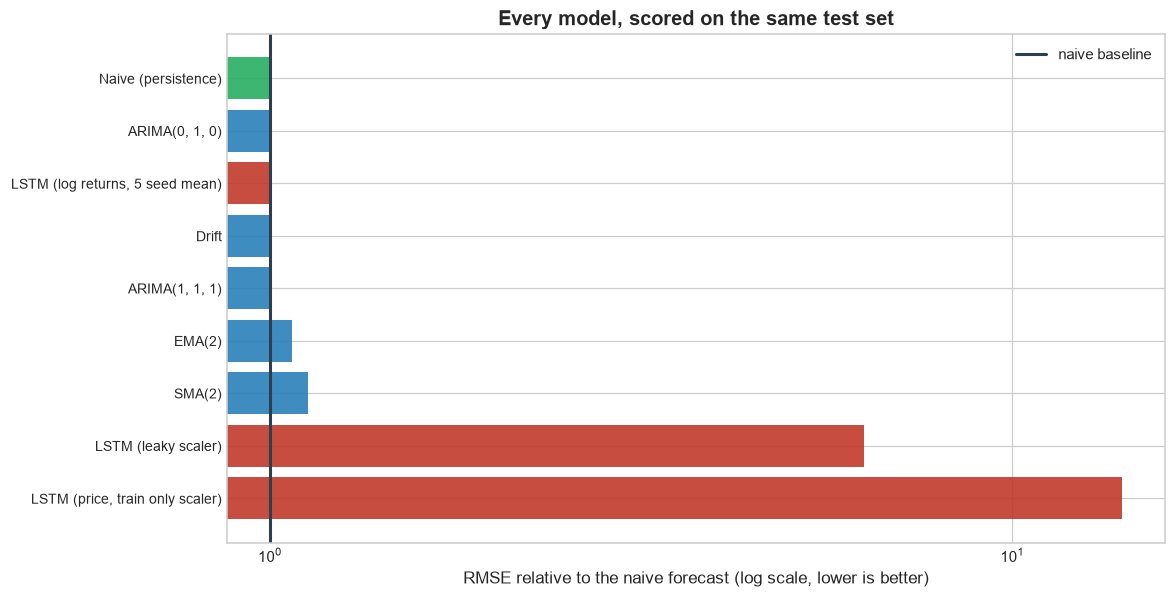

In [3]:
order = results.sort_values("RMSE").index
colors = ["#27ae60" if m == "Naive (persistence)" else
          "#c0392b" if "LSTM" in m else "#2980b9" for m in order]

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(range(len(order)), results.loc[order, "RMSE vs naive"], color=colors, alpha=0.9)
ax.axvline(1.0, color="#2c3e50", linewidth=2, label="naive baseline")
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order, fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("RMSE relative to the naive forecast (log scale, lower is better)")
ax.set_title("Every model, scored on the same test set")
ax.invert_yaxis()
ax.legend()

plots.save(fig, "06_rmse_comparison")
plt.show()

The log scale is necessary because the LSTM trained on price levels is fourteen times worse than
the baseline, which would flatten everything else on a linear axis.

Read the bars against the vertical line. Only one model sits marginally to its left, the single
seed log return LSTM, and section 3 shows why that does not survive.

---
## 2. No model can call direction

saved -> reports/figures/06_directional_accuracy.png


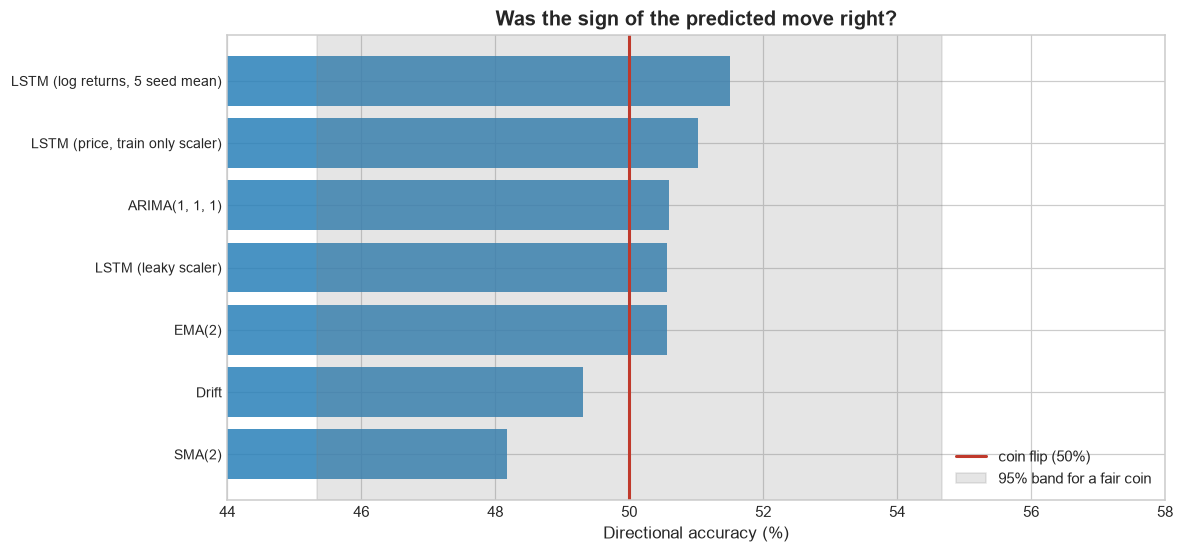

In [4]:
directional = results["Directional %"].dropna().sort_values()

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.barh(range(len(directional)), directional.values, color="#2980b9", alpha=0.85)
ax.axvline(50, color="#c0392b", linewidth=2, label="coin flip (50%)")
ax.axvspan(50 - 1.96 * se, 50 + 1.96 * se, color="grey", alpha=0.2,
           label="95% band for a fair coin")
ax.set_yticks(range(len(directional)))
ax.set_yticklabels(directional.index, fontsize=9)
ax.set_xlim(44, 58)
ax.set_xlabel("Directional accuracy (%)")
ax.set_title("Was the sign of the predicted move right?")
ax.legend(loc="lower right")

plots.save(fig, "06_directional_accuracy")
plt.show()

Every model except one sits inside the grey band, which is the range a fair coin produces over 441
days.

Naive and ARIMA(0,1,0) are absent because they take no directional position at all. They predict no
change, so there is nothing to score, and inventing a number for them would be dishonest rather
than informative.

---
## 3. The one apparent exception

The single seed log return LSTM reached 55.15 percent, roughly two standard errors above chance,
with a one sided binomial p value of 0.018. On its own that reads as a real edge.

Running the identical model across five random seeds gives a mean of 51.51 percent, p = 0.28, and
it beat the naive RMSE in one run out of five.

The 55 percent was the lucky draw. Reporting it alone would have been a false positive produced
entirely by the protocol, not by the market.

In [5]:
summary = pd.DataFrame({
    "claim": ["Single run (seed 7)", "Five seed mean"],
    "directional %": [55.15, 51.51],
    "z vs coin flip": [round((55.15 - 50) / se, 2), round((51.51 - 50) / se, 2)],
    "one sided p": [0.018, 0.284],
    "beats naive RMSE": ["yes", "no (1 of 5 runs)"],
})
summary.set_index("claim")

,directional %,z vs coin flip,one sided p,beats naive RMSE
claim,,,,
Single run (seed 7),55.15,2.16,0.018,yes
Five seed mean,51.51,0.63,0.284,no (1 of 5 runs)


---
## 4. Conclusions

**1. The naive forecast was not beaten.** Across baselines, ARIMA and three LSTM variants, nothing
produced a reliable improvement on tomorrow equals today.

**2. Classical model selection agreed.** Given a grid of ARIMA orders, AIC chose (0,1,0), which is
the random walk, which is the naive forecast.

**3. Data leakage roughly halved the reported error.** The conventional practice of fitting the
scaler before splitting improved RMSE from about 30 to about 13 with no change to the model. It did
not create a good result, it concealed a diagnosis.

**4. Predicting price levels is the wrong problem framing.** The test period sat above the entire
training range, so a min max scaled network could not reach it. Predicting log returns removed the
problem, because returns are stationary and prices are not.

**5. The apparent directional edge was seed variance.** This is the result the project exists to
demonstrate. Every safeguard here, train only scaling, held out validation, baselines on identical
splits, directional accuracy, and the seed sweep, targets one specific way of fooling yourself. The
seed sweep is the one that caught something.

### What would actually be needed

Not a bigger network. Daily closing prices contain very little forecastable signal about direction,
which is what an efficient market implies and what notebook 03 measured directly.

Plausible directions, none of which are more layers:

- **Volatility instead of direction.** Notebook 03 found absolute returns strongly autocorrelated
  out past sixty lags. GARCH style models forecast that well, and it is a genuinely tractable
  problem on this exact data.
- **Information beyond price.** Earnings, subscriber numbers, news sentiment. No model here could
  have anticipated the 35 percent single day fall in April 2022, because none of them saw anything
  except past prices.
- **Higher frequency data**, where microstructure effects create short lived predictability.
- **Cross sectional models** ranking many stocks against each other rather than forecasting one in
  isolation.

### Limitations

- One ticker. Nothing here is validated across a universe of stocks.
- One test period, covering a large drawdown. A different window could give different numbers.
- Five seeds is enough to detect the variance, not to characterise it precisely.
- No transaction costs, slippage, market impact or liquidity constraints, so directional accuracy
  would not translate into profit even if it were real.
- Daily bars only, and no data beyond price and volume.
- Educational project. Not investment advice.

In [6]:
final = results.sort_values("RMSE")[["RMSE", "RMSE vs naive", "MAE", "MAPE %", "Directional %"]]
final.to_csv(config.DATA_PROCESSED / "results_final.csv")
print("saved -> data/processed/results_final.csv")
print()
print(final.to_string())

saved -> data/processed/results_final.csv

                                    RMSE  RMSE vs naive      MAE  MAPE %  Directional %
model                                                                                  
Naive (persistence)               2.1295          1.000   1.4774   1.519            NaN
ARIMA(0, 1, 0)                    2.1295          1.000   1.4774   1.519            NaN
LSTM (log returns, 5 seed mean)   2.1295          1.000   1.4770   1.519          51.51
Drift                             2.1297          1.000   1.4776   1.519          49.31
ARIMA(1, 1, 1)                    2.1303          1.000   1.4790   1.520          50.60
EMA(2)                            2.2831          1.072   1.6070   1.647          50.57
SMA(2)                            2.3957          1.125   1.6988   1.743          48.17
LSTM (leaky scaler)              13.4420          6.312  11.4099  10.696          50.57
LSTM (price, train only scaler)  29.9704         14.074  28.2839  27.654     